## Загрузка и обзор данных

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Описание:
* *InvoiceNo* — номер заказа
* *StockCode* — код товара
* *Description* — описание товара
* *Quantity* — количество товара
* *InvoiceDate* — дата и время транзакции
* *UnitPrice* — цена товара
* *CustomerID* — идентификатор пользователя
* *Country* — страна пользователя

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Предобработка данных

Перед началом работы с данным необходимо удостовериться, что они не содержат пропусков, некорректных значений и дубликатов.

In [4]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.describe().round(3)

,Quantity,UnitPrice,CustomerID
count,541909.000,541909.000,406829.000
mean,9.552,4.611,15287.691
std,218.081,96.760,1713.600
min,-80995.000,-11062.060,12346.000
25%,1.000,1.250,13953.000
50%,3.000,2.080,15152.000
75%,10.000,4.130,16791.000
max,80995.000,38970.000,18287.000


In [6]:
df.duplicated().sum()

np.int64(5268)

Пропуски есть в колонках *Description* и *CustomerID*; в первом случае их можно заполнить, а во втором необходимо удалить.

В колонках *Quantity* и *UnitPrice* присутствуют отрицательные значения, которые стоит почистить.

Также есть некоторое количество дубликатов, которые мы удалим.

In [7]:
df = df.dropna(subset=['CustomerID'])
df = df.fillna('No description')

In [8]:
(df['Quantity'] <= 0).sum(), (df['UnitPrice'] <= 0).sum()

(np.int64(8905), np.int64(40))

In [9]:
df = df[(df['Quantity'] > 0.0) & (df['UnitPrice'] > 0.0)].reset_index(drop=True)
df.describe().round(3)

,Quantity,UnitPrice,CustomerID
count,397884.000,397884.000,397884.000
mean,12.988,3.116,15294.423
std,179.332,22.098,1713.142
min,1.000,0.001,12346.000
25%,2.000,1.250,13969.000
50%,6.000,1.950,15159.000
75%,12.000,3.750,16795.000
max,80995.000,8142.750,18287.000


In [10]:
df = df.drop_duplicates()

Стоит применить feature engineering: привести значения к нужному типу, добавить колонку значения месяца транзакции (поскольку это может быть полезной расчетной единицей) и объема выручки, полученной за каждую транзакцию.

In [11]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(2)

In [12]:
df.nunique()

InvoiceNo      18532
StockCode       3665
Description     3877
Quantity         301
InvoiceDate    17282
UnitPrice        440
CustomerID      4338
Country           37
YearMonth         13
Revenue         2699
dtype: int64

## EDA и визуализация

Проведем разведочный анализ данных, чтобы выявить основные тенденции, закономерности и распределения основных переменных. Нас будут интересовать в первую очередь числовые значения (Quantity, UnitPrice, Revenue).

In [13]:
df.describe().round(2)

,Quantity,InvoiceDate,UnitPrice,Revenue
count,392692.00,392692,392692.00,392692.00
mean,13.12,2011-07-10 19:13:07.771892,3.13,22.63
min,1.00,2010-12-01 08:26:00,0.00,0.00
25%,2.00,2011-04-07 11:12:00,1.25,4.95
50%,6.00,2011-07-31 12:02:00,1.95,12.45
75%,12.00,2011-10-20 12:53:00,3.75,19.80
max,80995.00,2011-12-09 12:50:00,8142.75,168469.60
std,180.49,NaN,22.24,311.10


Разброс значений очень широкий; вероятно, есть много экстремальных значений. Посмотрим на ту же статистику для данных в пределах 99%-ного перцентиля, например, по Revenue.

In [14]:
df[df['Revenue'] < df['Revenue'].quantile(0.99)].describe().round(2)

,Quantity,InvoiceDate,UnitPrice,Revenue
count,388736.00,388736,388736.00,388736.00
mean,10.66,2011-07-10 20:43:01.542538,2.91,17.28
min,1.00,2010-12-01 08:26:00,0.00,0.00
25%,2.00,2011-04-07 11:16:00,1.25,4.95
50%,6.00,2011-07-31 12:34:00,1.95,11.85
75%,12.00,2011-10-20 13:13:00,3.75,19.50
max,3186.00,2011-12-09 12:50:00,195.00,203.40
std,22.48,NaN,3.85,23.28


Максимальные значения переменных стали сильно ниже, что говорит о сильно скошенном распределении. Визуализируем их, используя логарифмическую шкалу:

<Axes: xlabel='Revenue', ylabel='Count'>

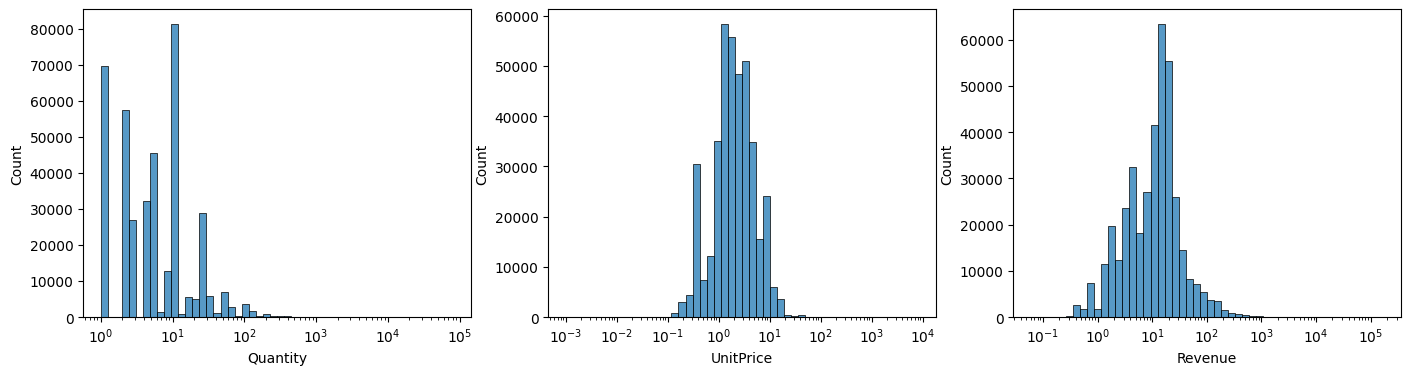

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(data=df['Quantity'], bins=50, log_scale=True, ax=ax[0])
sns.histplot(data=df['UnitPrice'], bins=50, log_scale=True, ax=ax[1])
sns.histplot(data=df['Revenue'], bins=50, log_scale=True, ax=ax[2])

Распределения сильно асимметричны, много экстремальных значений, но удалять мы их не будем, т. к. они скорее всего представляют собой реальные данные, отражающие ценных клиентов, а не выбросы (учитывая их количество и разброс), и их удаление может сказаться на дальнейших расчетах.

### Распределения выручки по странам, продуктам и во времени

Выручка (Revenue) представляет собой одну из важнейших переменных, поскольку отражает оборот и объем продаж компании. Она может варьировать в зависимости от значений других переменных, поэтому имеет смысл изучить ее распределение подробнее.

In [16]:
country_analysis = df.groupby('Country').agg({'Revenue': 'sum'}).round(2)
country_analysis = country_analysis.sort_values('Revenue', ascending=False)
country_analysis.head(10)

,Revenue
Country,
United Kingdom,7285024.64
Netherlands,285446.34
EIRE,265262.46
Germany,228678.40
France,208934.31
Australia,138453.81
Spain,61558.56
Switzerland,56443.95
Belgium,41196.34


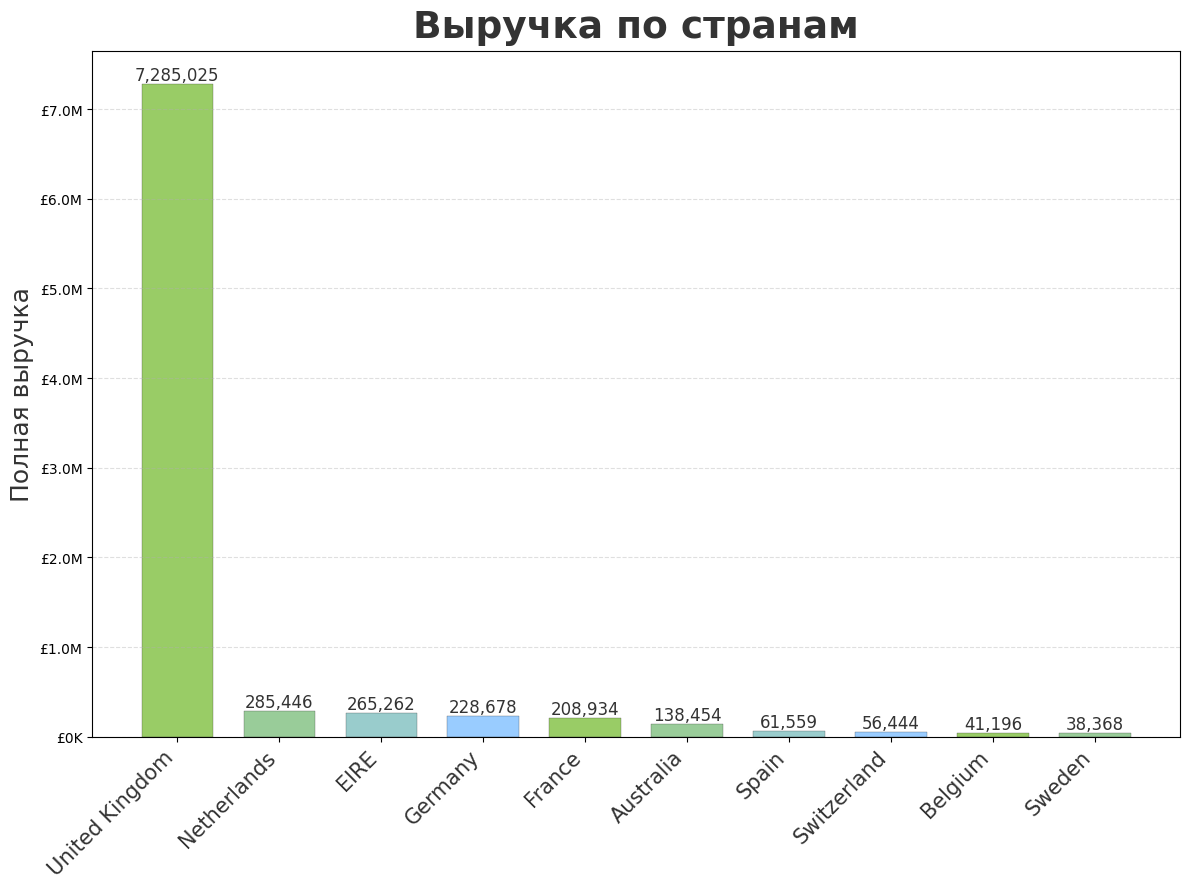

In [17]:
colors = ['#99cc66', '#99cc99', '#99cccc', '#99ccff']
top_countries = country_analysis.head(10)

plt.figure(figsize=(12, 9))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000000:.1f}M' if x >= 1000000 else f'£{x/1000:.0f}K'))

bars = plt.bar(range(len(top_countries)), 
               top_countries['Revenue'], 
               color=[colors[i % len(colors)] for i in range(len(top_countries))],
               width=0.7,
               edgecolor='#333',
               linewidth=0.2)

plt.title('Выручка по странам', fontsize=27, fontweight='bold', pad=10, color='#333')
plt.ylabel('Полная выручка', fontsize=18, color='#333')
plt.xticks(range(len(top_countries)), top_countries.index, rotation=45, ha='right', fontsize=15, color='#333')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=12, color='#333')

plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

В основном компании продает свои товары в Великобритании и странах Европы, а также в Австралии.

In [18]:
product_analysis = df.groupby('Description').agg({'Revenue': 'sum'}).round(2)
product_analysis = product_analysis.sort_values('Revenue', ascending=False)
product_analysis

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
...,...
PURPLE FRANGIPANI HAIRCLIP,0.85
VINTAGE BLUE TINSEL REEL,0.84
SET 12 COLOURING PENCILS DOILEY,0.65


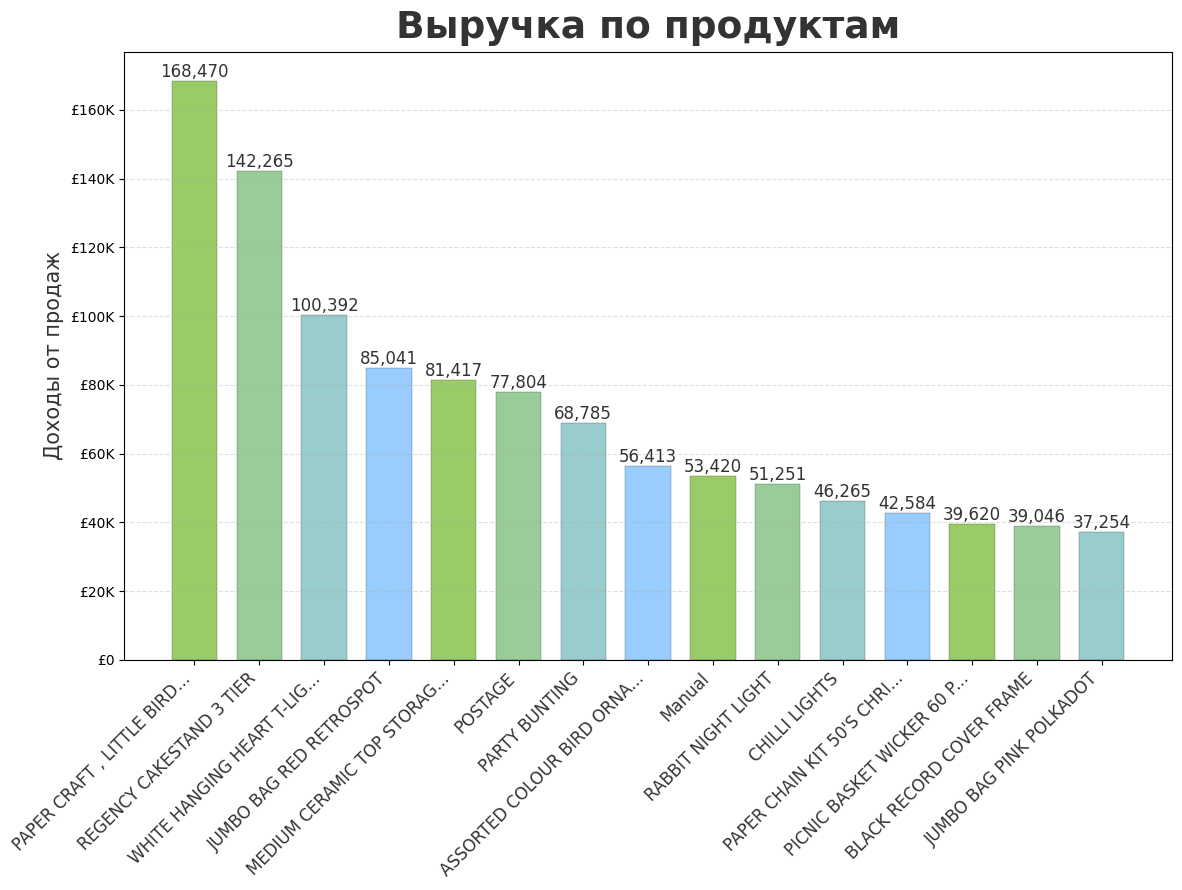

In [19]:
colors = ['#99cc66', '#99cc99', '#99cccc', '#99ccff']
top_products = product_analysis.head(15).reset_index()

plt.figure(figsize=(12, 9))
plt.style.use('default')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K' if x >= 1000 else f'£{x:.0f}'))

bars = plt.bar(range(len(top_products)), 
               top_products['Revenue'], 
               color=[colors[i % len(colors)] for i in range(len(top_products))],
               width=0.7,
               edgecolor='#333',
               linewidth=0.2)

plt.title('Выручка по продуктам', fontsize=27, fontweight='bold', pad=10, color='#333')
plt.ylabel('Доходы от продаж', fontsize=15, color='#333')
product_names = [name[:25] + '...' if len(name) > 25 else name for name in top_products['Description']]
plt.xticks(range(len(top_products)), product_names, rotation=45, ha='right', fontsize=12, color='#333')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=12, color='#333')

plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

Магазин торгует самыми разнообразными товарами для дома, и в ассортименте хорошо выражены товары, пользующиеся большим спросом и приносящие много прибыли.

In [20]:
monthly_sales = df.groupby('YearMonth').agg({'Revenue': 'sum'}).round(2).reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
monthly_sales

,YearMonth,Revenue
0,2010-12,570422.73
1,2011-01,568101.31
2,2011-02,446084.92
3,2011-03,594081.76
4,2011-04,468374.33
5,2011-05,677355.15
6,2011-06,660046.05
7,2011-07,598962.90
8,2011-08,644051.04
9,2011-09,950690.20


In [21]:
top_data = df[df['Description'].isin(top_products['Description'])]
monthly_top = top_data.groupby('YearMonth').agg({'Revenue': 'sum'}).reset_index()
monthly_top

,YearMonth,Revenue
0,2010-12,57765.22
1,2011-01,125612.18
2,2011-02,36511.11
3,2011-03,57031.62
4,2011-04,53130.98
5,2011-05,74220.09
6,2011-06,91734.66
7,2011-07,57260.30
8,2011-08,60452.70
9,2011-09,58721.07


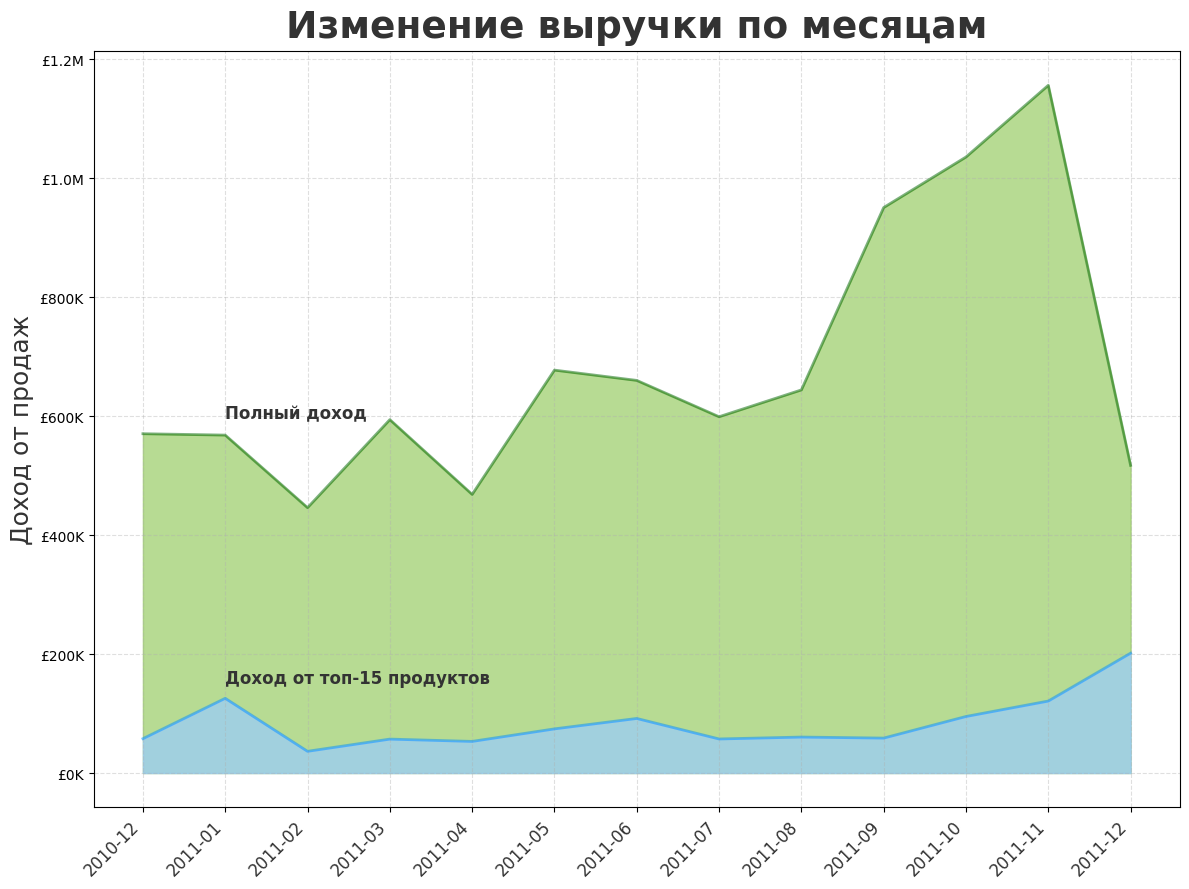

In [22]:
colors = ['#99cc66', '#99cc99', '#99cccc', '#99ccff']

x = range(len(monthly_sales))
y = monthly_sales['Revenue']
y_top = monthly_top['Revenue']

plt.figure(figsize=(12, 9))
plt.style.use('default')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000000:.1f}M' if x >= 1000000 else f'£{x/1000:.0f}K'))
plt.plot(x, y, color='#006600', linewidth=2, alpha=0.5)
plt.fill_between(x, y, alpha=0.7, color=colors[0], label='Total Sales')
plt.plot(x, y_top, color='#008fff', linewidth=2, alpha=0.5)
plt.fill_between(x, y_top, alpha=0.7, color=colors[3])

max_height = 568101.31
min_height = 125612.18
idx = 1
plt.annotate('Полный доход', xy=(idx, max_height*1.05),
             ha='left', fontsize=12, fontweight='bold', color='#333')
plt.annotate('Доход от топ-15 продуктов', xy=(idx, min_height*1.2),
             ha='left', fontsize=12, fontweight='bold', color='#333')

plt.title('Изменение выручки по месяцам', fontsize=27, fontweight='bold', pad=10, color='#333')
plt.ylabel('Доход от продаж', fontsize=18, color='#333')
plt.xticks(x, monthly_sales['YearMonth'], rotation=45, ha='right', fontsize=12, color='#333')

plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.grid(axis='x', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

In [23]:
max_idx = monthly_sales['Revenue'].idxmax()
max_sale = monthly_sales['Revenue'].max()
avg_month = monthly_sales['Revenue'].mean()
print(f'Максимальные продажи наблюдались в ноябре 2011 и составили £ {max_sale:,.0f}.\nСреднемесячные продажи составляют £ {avg_month:,.0f}.')

Максимальные продажи наблюдались в ноябре 2011 и составили £ 1,156,206.
Среднемесячные продажи составляют £ 683,631.


В течение года ежемесячная выручка колебалась около £ 600,000. Рост продаж осенью (и особенно в ноябре), вероятнее всего, связан с сезонным увеличением спроса в преддверии рождественских праздников и активностью маркетинговых кампаний Черной пятницы и др. В этот же период выражен рост продаж товаров из топ-15. Стоит также отметить, что данные за декабрь 2011 года неполные, что может усиливать визуальный контраст на фоне ноября.

## Анализ клиентской базы

Еще одним важным показателем является поведение пользователей и их отношение к продукту - интернет-магазину.

Рассмотрим клиентские метрики, которые были бы важны для этой компании: доход с каждого покупателя (Revenue), количество покупок (Orders), средний чек (AverageOrder)

In [24]:
customers = df.groupby('CustomerID').agg({'Revenue': 'sum', 'InvoiceNo': 'nunique'})
customers.columns = ['Revenue', 'Orders']
customers['AverageOrder'] = (customers['Revenue'] / customers['Orders']).round(2)
customers

,Revenue,Orders,AverageOrder
CustomerID,,,
12346,77183.60,1,77183.60
12347,4310.00,7,615.71
12348,1797.24,4,449.31
12349,1757.55,1,1757.55
12350,334.40,1,334.40
...,...,...,...
18280,180.60,1,180.60
18281,80.82,1,80.82
18282,178.05,2,89.02


Колонка Revenue отражает Lifetime Value (LTV) каждого клиента. Этот показатель дает понять, какие покупатели имеют бóльшую ценость для компании и кого выгоднее удерживать.

In [25]:
customers.describe().round(2)

,Revenue,Orders,AverageOrder
count,4338.00,4338.00,4338.00
mean,2048.69,4.27,417.65
std,8985.23,7.70,1796.51
min,3.75,1.00,3.45
25%,306.48,1.00,177.86
50%,668.57,2.00,291.94
75%,1660.60,5.00,428.28
max,280206.02,209.00,84236.25


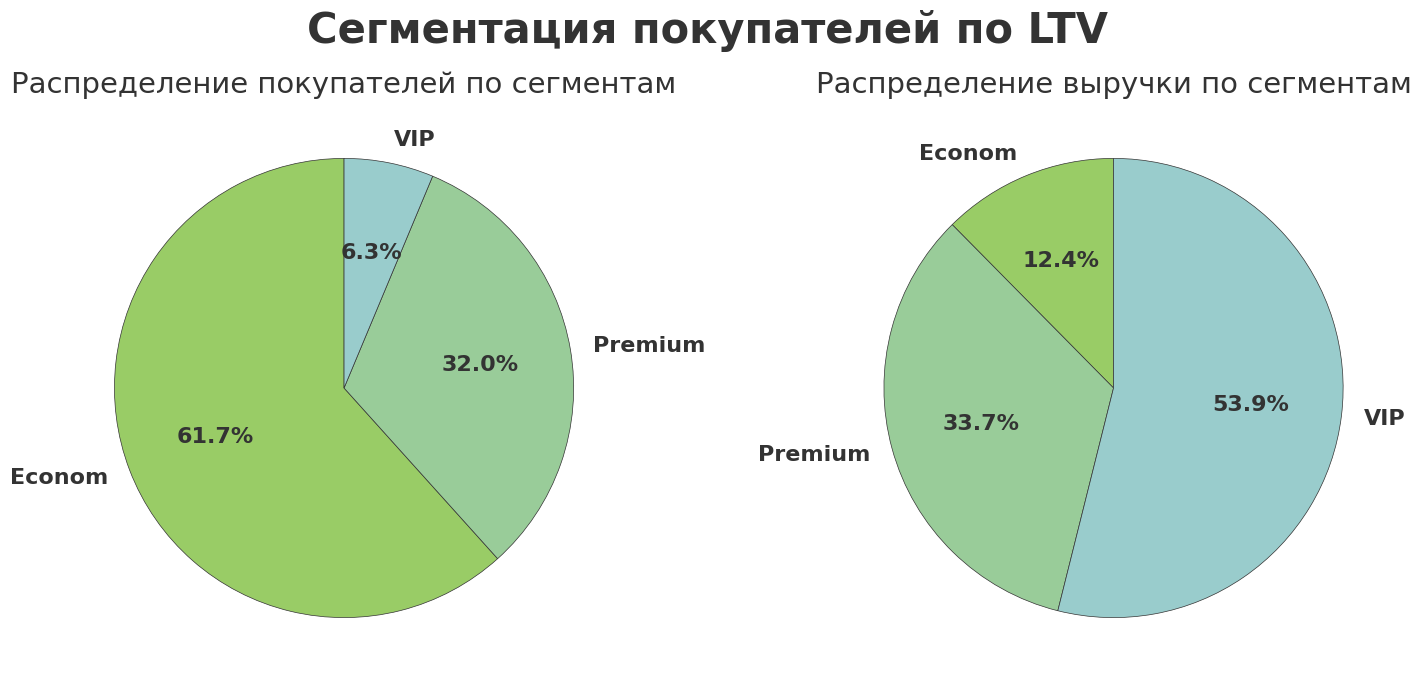

In [26]:
colors = ['#99cc66', '#99cc99', '#99cccc', '#99ccff']
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Сегментация покупателей по LTV', fontsize=30, fontweight='bold', y=1.05, color='#333')

def segmentation(value):
    if value >= 5000:
        return 'VIP'
    elif value >= 1000:
        return 'Premium'
    else:
        return 'Econom'

customers['Segment'] = customers['Revenue'].apply(segmentation)
segment_analysis = customers.groupby('Segment').agg({'Segment': 'count', 'Revenue': 'sum'})
segment_analysis['SegmentPercentage'] = (segment_analysis['Segment'] / segment_analysis['Segment'].sum() * 100).round(1)
segment_analysis['RevenuePercentage'] = (segment_analysis['Revenue'] / segment_analysis['Revenue'].sum() * 100).round(1)

sizes = segment_analysis['SegmentPercentage']
amounts = segment_analysis['RevenuePercentage']
labels = segment_analysis.index

ax1 = axes[0]
ax1.pie(sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops = {'linewidth': 0.5, 'edgecolor': '#333'},
        textprops={'fontsize': 16, 'fontweight': 'bold', 'color': '#333'})
ax1.set_title('Распределение покупателей по сегментам', fontsize=21, color='#333')

ax2 = axes[1]
ax2.pie(amounts,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops = {'linewidth': 0.5, 'edgecolor': '#333'},
        textprops={'fontsize': 16, 'fontweight': 'bold', 'color': '#333'})
ax2.set_title('Распределение выручки по сегментам', fontsize=21, color='#333')

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.1, wspace=0.2)
plt.show()

Получается, что основная выручка идёт с VIP-сегмента (отсечка на уровне £ 5000), и 6.3% клиентов приносят 53.9% прибыли.

Можем посчитать частоту покупок (purchase frequency) по каждому сегменту:

In [27]:
segment_freq = customers.groupby('Segment').agg({'Orders': 'mean'})
segment_freq

,Orders
Segment,
Econom,1.829095
Premium,5.764029
VIP,20.543796


VIP-клиенты покупают чаще, чем в остальных группах, и при этом приносят более половины от всей выручки. Клиенты эконом-класса совершают в среднем 1-2 покупки, и выручка от них составляет около 12% от общей.

Для бизнеса также будет полезной информация о количестве активных пользователей в разные временные периоды и о его динамике.

In [28]:
dau = df.groupby(df['InvoiceDate'].dt.date).agg({'CustomerID': 'nunique'})
wau = df.groupby(df['InvoiceDate'].dt.to_period('W')).agg({'CustomerID': 'nunique'})
mau = df.groupby(df['InvoiceDate'].dt.to_period('M')).agg({'CustomerID': 'nunique'})
mau

,CustomerID
InvoiceDate,
2010-12,885
2011-01,741
2011-02,758
2011-03,974
2011-04,856
2011-05,1056
2011-06,991
2011-07,949
2011-08,935


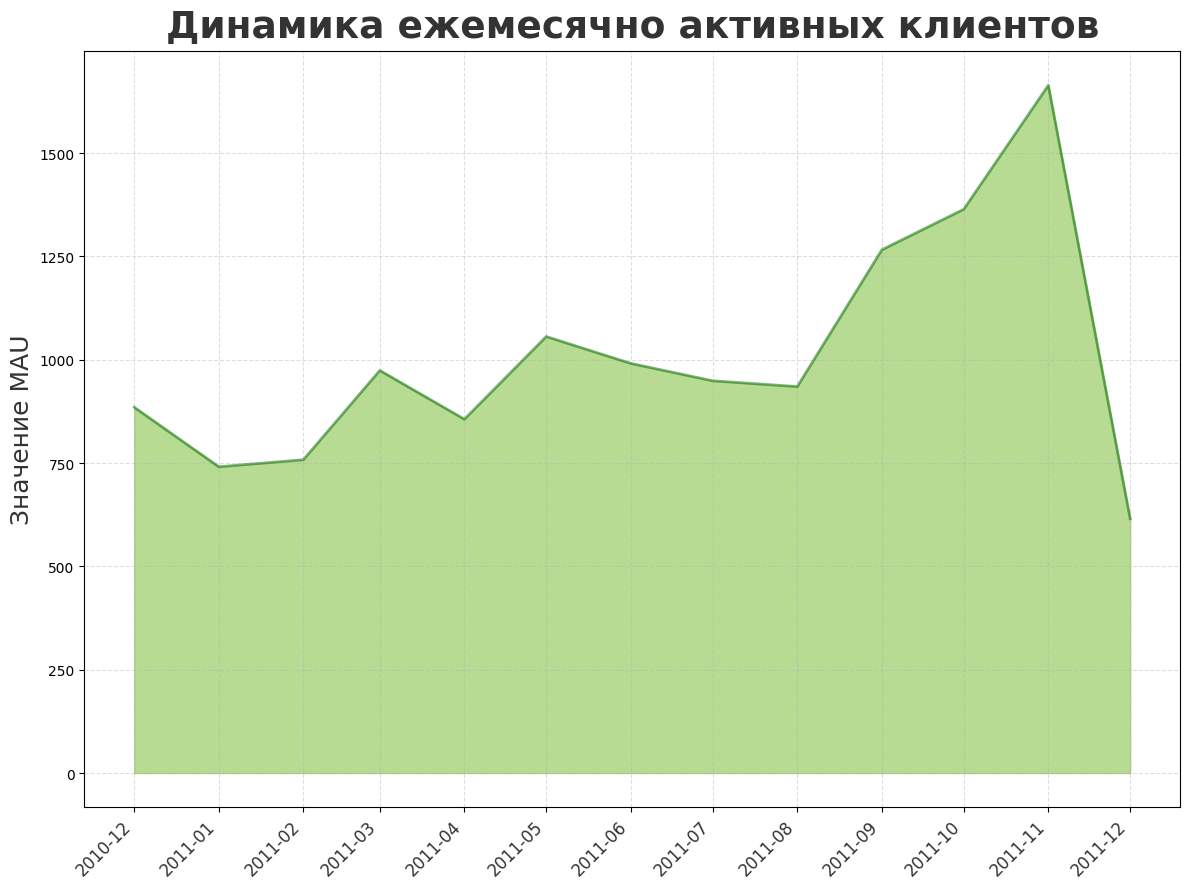

In [29]:
colors = ['#99cc66', '#99cc99', '#99cccc', '#99ccff']

x = mau.index.to_timestamp()
y = mau.values

plt.figure(figsize=(12, 9))
ax = plt.gca()
plt.plot(x, y, linewidth=2, alpha=0.5, color='#006600')
plt.fill_between(x, y.squeeze(), alpha=0.7, color=colors[0], label='Total Sales')

plt.title('Динамика ежемесячно активных клиентов', fontsize=27, fontweight='bold', pad=10, color='#333')
plt.ylabel('Значение MAU', fontsize=18, color='#333')
plt.xticks(x, monthly_sales['YearMonth'], rotation=45, ha='right', fontsize=12, color='#333')

plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.grid(axis='x', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

Можно заметить тенденции, схожие с изменением величины выручки с течением времени - например, увеличение потока клиентов к ноябрю. Также не стоит забыть про неполноту данных за декабрь 2011.

## Ключевые метрики

In [30]:
total_revenue = df['Revenue'].sum()
total_products = df['Description'].nunique()
num_countries = df['Country'].nunique()
total_customers = df['CustomerID'].nunique()
total_invoices = df['InvoiceNo'].nunique()
avg_invoice = round(total_revenue / total_invoices, 2)
arpu = round(total_revenue / total_customers, 2)
frequency = round(total_invoices / total_customers, 2)

timespan = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days
atbp = round(timespan / frequency)

invoices = customers['Orders']
repeats = invoices[invoices > 1].count()
repeat_rate = round((repeats / total_customers) * 100, 2)

last_date = df['InvoiceDate'].max()
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()
threshold = last_date - pd.DateOffset(months=3)
lost_customers = last_purchase[last_purchase < threshold]
churn_rate = round((len(lost_customers) / total_customers) * 100, 2)


metrics = f'''
Общая выручка: £ {total_revenue:.2f}
Уникальные товары: {total_products} позиций
География продаж: {num_countries} стран
Всего клиентов: {total_customers}
Всего транзакций: {total_invoices}
Средний чек (AOV): £ {avg_invoice}
Средняя выручка на клиента (ARPU): £ {arpu}
Частота покупок (PF): {frequency}
Среднее время между покупками (ATBP): {atbp} дней
Коэффициент повторных покупок (RPR): {repeat_rate}%
Коэффициент оттока (Churn rate): {churn_rate}%
'''
print(metrics)


Общая выручка: £ 8887208.89
Уникальные товары: 3877 позиций
География продаж: 37 стран
Всего клиентов: 4338
Всего транзакций: 18532
Средний чек (AOV): £ 479.56
Средняя выручка на клиента (ARPU): £ 2048.69
Частота покупок (PF): 4.27
Среднее время между покупками (ATBP): 87 дней
Коэффициент повторных покупок (RPR): 65.58%
Коэффициент оттока (Churn rate): 33.31%



Значения метрик указывают на относительно небольшое  клиентов, высокий средний чек, высокую долю повторных покупок, но заметный отток пользователей.

Выручка сильно концентрируется среди ограниченного числа клиентов, что может быть характерно для e-commerce с крупными заказами. В среднем, клиенты делают 4.27 покупки за год; высокий RPR (65.58%) указывает на то, что пользователи склонны возвращаться за повторными покупками, и у магазина есть лояльная аудитория. Несмотря на наличие повторных покупок, частота заказов остаётся умеренной, что оставляет потенциал для стратегий удержания клиентов.

## RFM-анализ

Проведем RFM-анализ для определения групп самых лояльных и приносящих больше всего денег клиентов и самых неактивных.

Посчитаем для кажого клиента давность (Recency), частоту (Frequency) и сумму (Monetary) его покупок, и каждую метрику охарактеризуем по шкале от 1 до 3 - чем больше балл, тем лучше.

In [31]:
rfm_data = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()
rfm_data.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm_data = rfm_data[rfm_data['Monetary'] > 0]

def rfm_score(df, score):
    try:
        return pd.qcut(df[score], q=3, labels=[1, 2, 3], duplicates='drop').astype(int)
    except:
        return pd.qcut(df[score].rank(method='first'), q=3, labels=[1, 2, 3]).astype(int)

rfm_data['R_Score'] = 4 - rfm_score(rfm_data, 'Recency')
rfm_data['F_Score'] = rfm_score(rfm_data, 'Frequency')
rfm_data['M_Score'] = rfm_score(rfm_data, 'Monetary')
rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)
rfm_data

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,325,1,77183.60,1,1,3,113
1,12347,1,7,4310.00,3,3,3,333
2,12348,74,4,1797.24,2,2,3,223
3,12349,18,1,1757.55,3,1,3,313
4,12350,309,1,334.40,1,1,1,111
...,...,...,...,...,...,...,...,...
4333,18280,277,1,180.60,1,2,1,121
4334,18281,180,1,80.82,1,2,1,121
4335,18282,7,2,178.05,3,2,1,321
4336,18283,3,16,2045.53,3,3,3,333


In [32]:
def segment_customers(row):
    if row['RFM_Score'] == '333':
        return 'Regular'
    elif row['R_Score'] == 3 and row['F_Score'] != 1:
        return 'Perspective'
    elif row['R_Score'] == 3 and row['F_Score'] == 1:
        return 'New Customers'
    elif row['R_Score'] == 2 and row['F_Score'] == 3:
        return 'Loyal Sleeping'
    elif row['R_Score'] == 2 and row['F_Score'] != 3:
        return 'Sleeping'
    elif row['R_Score'] == 1 and row['F_Score'] != 1:
        return 'Loyal Non-Active'
    else:
        return 'Lost'

rfm_data['Segment'] = rfm_data.apply(segment_customers, axis=1)

rfm_summary = rfm_data.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean', 
    'Monetary': ['mean', 'sum'],
    'CustomerID': 'count'
}).round(2)
rfm_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue', 'Customer_Count']
rfm_summary['Revenue_Percentage'] = (rfm_summary['Total_Revenue'] / rfm_summary['Total_Revenue'].sum() * 100).round(1)
rfm_summary = rfm_summary.sort_values('Total_Revenue', ascending=False)
rfm_summary


,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Count,Revenue_Percentage
Segment,,,,,,
Regular,8.70,12.82,7255.50,5245729.75,723,59.0
Loyal Sleeping,46.88,6.55,2681.00,1179640.62,440,13.3
Sleeping,53.76,1.77,705.78,698016.52,989,7.9
Loyal Non-Active,176.52,2.97,1088.94,681674.64,626,7.7
Perspective,12.11,3.11,1186.90,678904.30,572,7.6
Lost,240.79,1.00,426.10,348974.07,819,3.9
New Customers,14.00,1.00,321.12,54268.99,169,0.6


Стратегии работы с сегментами:
* Постоянные (Regular) - предоставлять персональное обслуживание;
* Лояльные спящие (Loyal Sleeping) - рассылать специальные подборки продуктов, рекомендации;
* Спящие (Sleeping) - предлагать новые товары, специальные скидки;
* Лояльные, потерявшие активность (Loyal Non-Active) - рассылать специальные предложения, скидки, программы лояльности;
* Перспективные (Perspective) - не предлагать скидки, но предоставлять персональное обслуживание и рекомендации;
* Потерянные (Lost) - напомнить о себе, предложив акции или промокоды;
* Новички (New Customers) - предлагать поддержку при онбординге.

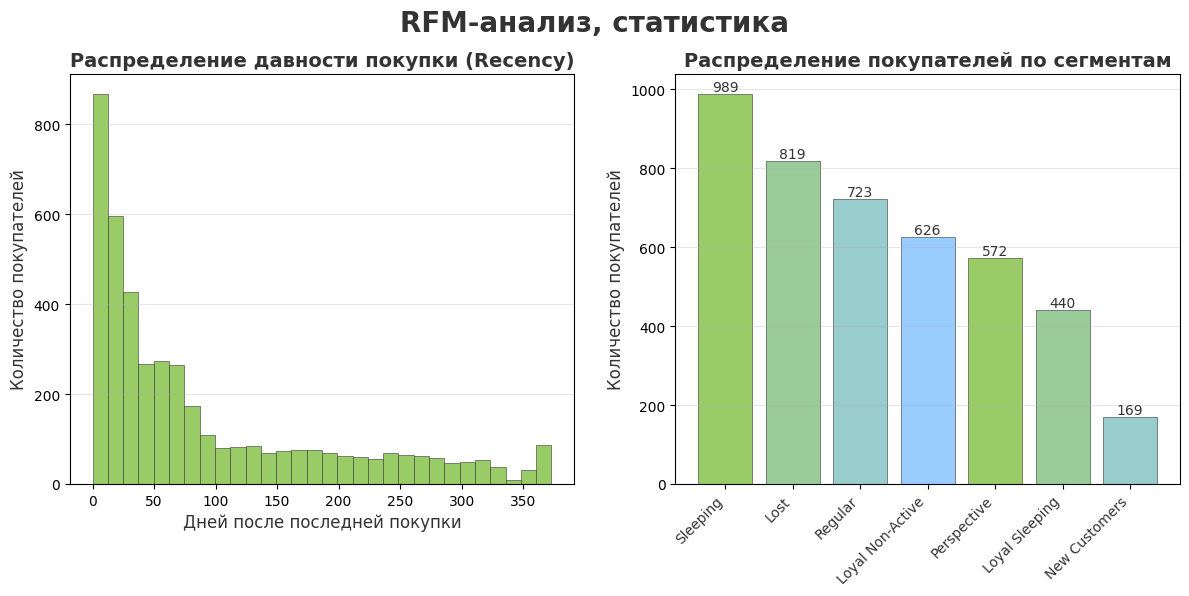

In [33]:
colors = ['#99cc66', '#99cc99', '#99cccc', '#99ccff']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('RFM-анализ, статистика', fontsize=20, fontweight='bold', y=1.05, color='#333')

ax1 = axes[0]
ax1.hist(rfm_data['Recency'], bins=30, color=colors[0], edgecolor='#333', linewidth=0.4)
ax1.set_title('Распределение давности покупки (Recency)', fontsize=14, fontweight='bold', color='#333')
ax1.set_xlabel('Дней после последней покупки', fontsize=12, color='#333')
ax1.set_ylabel('Количество покупателей', fontsize=12, color='#333')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
segment_counts = rfm_data['Segment'].value_counts()
bars = ax2.bar(range(len(segment_counts)), segment_counts.values, 
               color=[colors[i % len(colors)] for i in range(len(segment_counts))],
               edgecolor='#333', linewidth=0.4)
ax2.set_title('Распределение покупателей по сегментам', fontsize=14, fontweight='bold', color='#333')
ax2.set_xticks(range(len(segment_counts)))
ax2.set_xticklabels(segment_counts.index, rotation=45, ha='right', color='#333')
ax2.set_ylabel('Количество покупателей', fontsize=12, color='#333')
ax2.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', color='#333')

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.1, wspace=0.2)
plt.show()

Несмотря на большое количество недавних покупок (ноябрь-декабрь 2011), значительную часть клиентов составляют сегменты "спящих" и "потерянных", которые совершили очень мало покупок на небольшую сумму. Стоит сделать ставку на поддержание retention этих групп путем реализации стратегий.

## Когортный анализ

Для оценки Retention rate целесообразно провести когортный анализ, чтобы оценивать поведение клиентов с течением времени и их лояльность, а также наблюдать динамику изменения метрики.

Когорты пользователей будем определять по признаку месяца регистрации их первой покупки. 

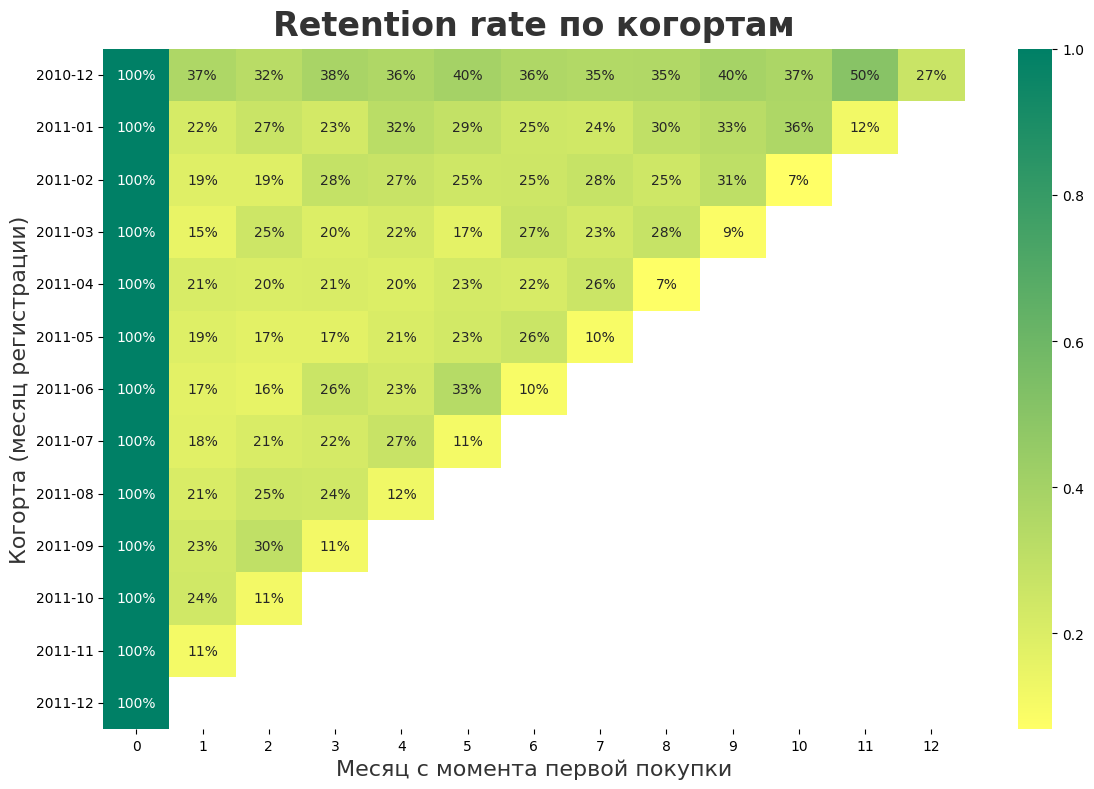

In [34]:
cohort_df = df[['CustomerID', 'InvoiceDate', 'YearMonth']]
cohort_df['CohortMonth'] = cohort_df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
cohort_df['CohortIndex'] = (cohort_df['YearMonth'].dt.year - cohort_df['CohortMonth'].dt.year) * 12 + (cohort_df['YearMonth'].dt.month - cohort_df['CohortMonth'].dt.month)

cohort_data = cohort_df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

plt.figure(figsize=(12, 8))
ax = plt.gca()
sns.heatmap(retention, annot=True, fmt='.0%', cmap='summer_r')

plt.title('Retention rate по когортам', fontsize=24, fontweight='bold', pad=10, color='#333')
plt.xlabel('Месяц с момента первой покупки', fontsize=16, color='#333')
plt.ylabel('Когорта (месяц регистрации)', fontsize=16, color='#333')
plt.tight_layout()
plt.show()

Многие клиенты совершают только одну покупку, поэтому удержание падает уже после первого месяца. Наиболее устойчивое удержание наблюдается среди клиентов, совершивших первую покупку в декабре 2010-январе 2011. Это может быть связано с проведением в этот период маркетинговых акций по распродаже товаров, увеличению ассортимента и т. п.

Причина низкого удержания в остальных когортах может заключаться в отсутствии мотивации к повторным покупкам, в узконаправленном ассортименте магазина или же в неудачном пользовательском опыте.

## A/A-тест

Перед проведением A/B-тестов полезно проверять систему тестирования на корректность, а выборки пользователей - на однородность. Для этого проведем симуляцию А/А-теста. Разобьем всех клиентов на две группы, имеющие одинаковый опыт взаимодействия с интернет-магазином. В качестве метрики возьмем выручку на пользователя (Revenue per user).

Нулевая гипотеза:
метрика выручки на пользователя между двумя **одинаковыми** группами не различается статистически значимо.

In [35]:
np.random.seed(42)

aa_test_data = customers['Revenue'].reset_index()
aa_test_data['Group'] = np.random.choice(['A1', 'A2'], size=total_customers, p=[0.5, 0.5])
aa_test_data.head()

,CustomerID,Revenue,Group
0,12346,77183.60,A1
1,12347,4310.00,A2
2,12348,1797.24,A2
3,12349,1757.55,A2
4,12350,334.40,A1


In [36]:
aa_test_data.groupby('Group')['Revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
A1,2162.0,2026.908659,8563.787677,3.75,302.815,656.96,1612.055,259657.30
A2,2176.0,2070.327376,9387.163485,6.20,309.950,679.85,1707.190,280206.02


Видим, что число пользователей различается в обеих группах (2162 и 2176). Проверим Sample Ratio Mismatch:

In [37]:
expected = [0.5, 0.5]
observed = [2162.0, 2176.0]
stat, p_value = stats.chisquare(f_obs=observed, f_exp=[sum(observed)*r for r in expected])
print(f'Chi2: {stat:.4f}, p-value: {p_value:.4f}')

Chi2: 0.0452, p-value: 0.8317


p-value достаточно большое (>> 0.05), значит, SRM в данном случае нет, и видимым различием в количестве пользователей можно пренебречь.

Построим гистограммы для обеих групп и посмотрим на распределения значений Revenue. Для наглядности выберем логарифмическую шкалу, поскольку (как мы помним из EDA) распределение этой величины имеет очень длинный правый хвост.

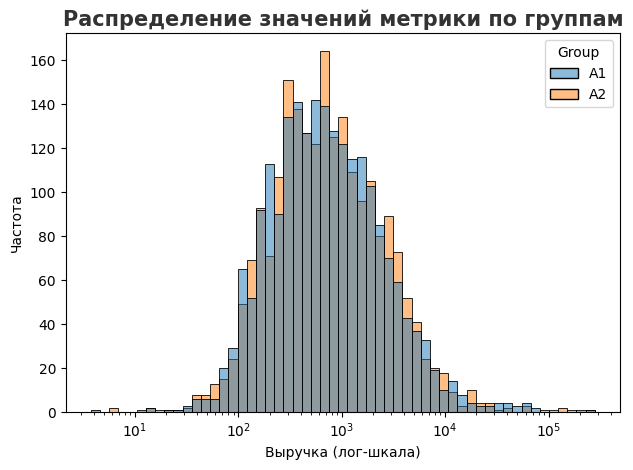

In [38]:
sns.histplot(data=aa_test_data,
             x='Revenue',
             hue='Group',
             log_scale=True)
plt.title('Распределение значений метрики по группам', fontsize=15, fontweight='bold', pad=5, color='#333')
plt.xlabel('Выручка (лог-шкала)', fontsize=10)
plt.ylabel('Частота', fontsize=10)
plt.tight_layout()
plt.show()

Распределения групп практически совпадают.

Метрика Revenue непрерывная, а распределения сильно асимметричные, поэтому имеет смысл провести бутстреп вместо однократного t-теста:

In [39]:
def bootstrap(data_A, data_B, n_iterations=10000):
    diffs = []
    pvalues = []
    for _ in range(n_iterations):
        group_A = np.random.choice(data_A, size=len(data_A), replace=True)
        group_B = np.random.choice(data_B, size=len(data_B), replace=True)
        diffs.append(group_B.mean() - group_A.mean())
        pvalues.append(stats.ttest_ind(group_A, group_B)[1])
    return diffs, pvalues

data_A1 = aa_test_data[aa_test_data['Group'] == 'A1']['Revenue']
data_A2 = aa_test_data[aa_test_data['Group'] == 'A2']['Revenue']
diffs_aa, pvalues_aa = bootstrap(data_A1, data_A2)

Получаем распределение разностей средних значений Revenue, считаем 95%-ный доверительный интервал (показан синим пунктиром)

In [40]:
lower = np.percentile(diffs_aa, 2.5)
upper = np.percentile(diffs_aa, 97.5)
print(f'95% ДИ: [{lower:.2f}; {upper:.2f}]\nСреднее: {np.array(diffs_aa).mean():.2f}')

95% ДИ: [-472.25; 578.98]
Среднее: 48.63


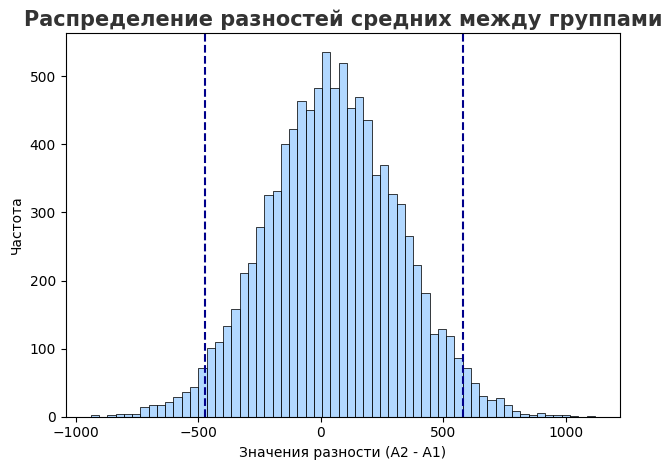

In [41]:
sns.histplot(data=diffs_aa, color='#99ccff')
plt.axvline(lower, linestyle='--', color='darkblue')
plt.axvline(upper, linestyle='--', color='darkblue')

plt.title('Распределение разностей средних между группами', fontsize=15, fontweight='bold', pad=5, color='#333')
plt.xlabel('Значения разности (A2 - A1)', fontsize=10)
plt.ylabel('Частота', fontsize=10)
plt.tight_layout()
plt.show()

Распределение близко к симметричному с центром около нуля; доверительный интервал включает 0.0, а значит, статистически значимой разницы между группами нет.

Оценим распределение p-value:

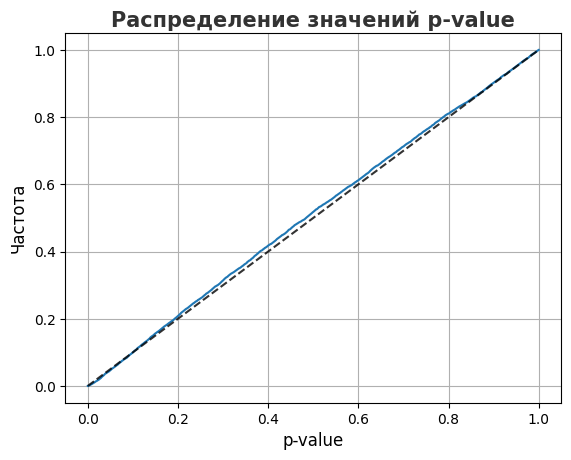

In [42]:
X = np.linspace(0, 1, 1000)
Y_aa = [np.mean(pvalues_aa < x) for x in X]
plt.plot(X, Y_aa)
plt.plot([0, 1], [0, 1], '--k', alpha=0.8)

plt.title('Распределение значений p-value', fontsize=15, fontweight='bold', pad=5, color='#333')
plt.xlabel('p-value', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid()
plt.show()

Распределение довольно близко к равномерному; можем считать, что A/A-тест проведен корректно и по такой же схеме проведём A/B-тест.

## A/B-тест

В реальной жизни при проектировании A/B-теста имеет смысл заранее рассчитать размер выборки и отслеживать несколько метрик в ходе эксперимента, а также проводить сегментацию. Однако в нашем случае данные очень ограничены, как по количеству, так и по признаковому описанию, поэтому целесообразно ограничиться одним тестом на всём объеме данных.

Предположим, что мы хотим выкатить новую рекомендательную систему и ожидаем, что она увеличит выручку (Revenue) от клиентов. 

Нулевая гипотеза:
метрика в группе пользователей, получивших **новую** версию, не изменится статистически значимо.

In [43]:
np.random.seed(142)

ab_test_data = customers['Revenue'].reset_index()
ab_test_data['Group'] = np.random.choice(['A', 'B'], size=total_customers, p=[0.5, 0.5])
ab_test_data.head()

,CustomerID,Revenue,Group
0,12346,77183.60,B
1,12347,4310.00,B
2,12348,1797.24,B
3,12349,1757.55,B
4,12350,334.40,A


С учетом результатов A/A-теста, примем, что абстрактная экспериментальная платформа достаточно стабильная, логгирование и рандомизация работают корректно и присвоенные группы не пересекаются. Поэтому в дальнейшем будем считать, что SRM отсутствует, и распределения между группами схожие.

Симуляция A/B-теста предполагает искусственное добавление эффекта в данные экспериментальной группы (группа В). Допустим, мы ожидаем, что эксперимент окажет воздействие на 50% пользователей. Случайно выбираем 50% значений Revenue в группе В и умножаем их на 1.2, предполагая средний эффект на пользователя равным 20%.

In [44]:
control = ab_test_data[ab_test_data['Group'] == 'A']
treatment = ab_test_data[ab_test_data['Group'] == 'B']
affected = np.random.choice(treatment.index, size=int(len(treatment)*0.5), replace=False)
treatment.loc[affected, 'Revenue'] *= 1.2

ab_test_data = pd.concat([control, treatment])
data_A = ab_test_data[ab_test_data['Group'] == 'A']['Revenue']
data_B = ab_test_data[ab_test_data['Group'] == 'B']['Revenue']
diffs_ab, pvalues_ab = bootstrap(data_A, data_B)

In [45]:
lower = np.percentile(diffs_ab, 2.5)
upper = np.percentile(diffs_ab, 97.5)
print(f'95% ДИ: [{lower:.2f}; {upper:.2f}]\nСреднее: {np.array(diffs_ab).mean():.2f}')

95% ДИ: [-370.02; 740.05]
Среднее: 197.52


In [46]:
uplift = (treatment["Revenue"].mean() / control["Revenue"].mean() - 1)
print(f'Прирост метрики: {uplift:.4f}')

Прирост метрики: 0.0967


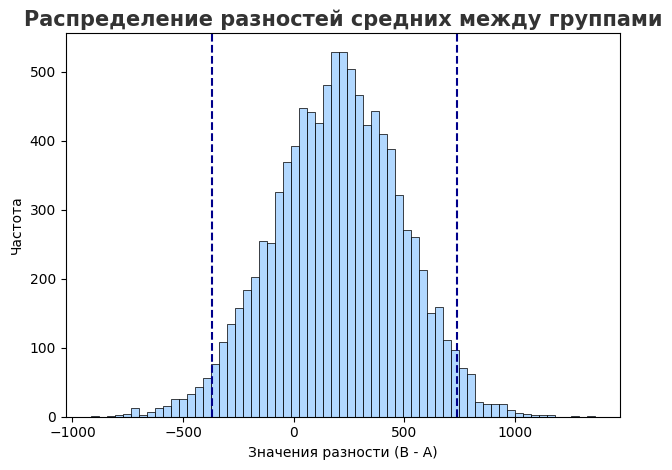

In [47]:
sns.histplot(data=diffs_ab, color='#99ccff')
plt.axvline(lower, linestyle='--', color='darkblue')
plt.axvline(upper, linestyle='--', color='darkblue')

plt.title('Распределение разностей средних между группами', fontsize=15, fontweight='bold', pad=5, color='#333')
plt.xlabel('Значения разности (B - A)', fontsize=10)
plt.ylabel('Частота', fontsize=10)
plt.tight_layout()
plt.show()

Распределение близко к симметричному со смещенным центром; доверительный интервал включает 0.0, поэтому статистически значимых различий между группами обнаружить не удалось, и оказанное воздействие можно считать неэффективным. В контексте продукта можно предварительно сделать вывод, что новую версию сайта раскатывать не стоит.

Отсутствие видимого эффекта может быть связано с недостаточным количеством данных, использованных в эксперименте. Заметный прирост метрики (+9,67%) мог бы служить поводом собрать больше данных и продолжить эксперимент.

Добиться статистической значимости можно было бы увеличением силы эффекта (например, с 20% до 80%) или увеличением числа пользователей, на которых он отразился, однако кратное повышение этих показателей не представляется реалистичным для бизнеса.

## Выводы
1. Распределения значений выручки, цены и количества проданных товаров сильно скошены с преобладанием небольших значений.
2. Магазин, вероятно, ориентирован на внутренний рынок Великобритании, но также продает товары во многие другие страны мира.
3. Ассортимент товаров разнообразный, представлен в основном товарами для дома и быта. Характерны сезонные колебания продаж.
4. Пользователи имеют склонность к совершению редких, но крупных покупок, что может быть связано со спецификой ассортимента или их недостаточной мотивированностью.
5. Бизнес во многом опирается на оптовую торговлю: небольшое число "VIP-клиентов", крупные заказы, редкие повторные покупки. При этом есть заметный отток и снижение удержания после 1-2 покупок.
6. Многие пользователи приходят разово. Значительную часть клиентов составляют сегменты "спящих" и "потерянных"; стоит сделать ставку на реактивацию этих групп, а также поддержку постонных клиентов.
7. Устойчивое удержание в некоторых когортах пользователей может быть связано с проведением маркетинговых акций или с увеличением ассортимента. Причина низкого удержания в остальных когортах может заключаться в узконаправленном ассортименте или же в неудачном пользовательском опыте.
8. Проведение симуляции A/B-теста показало отсутствие видимого эффекта, что может быть связано с недостаточностью данных. Однако после воздействия обнаруживается заметный прирост выручки на пользователя, что могло бы служить поводом продолжить эксперимент и собрать больше данных.